# AgroOpt — Notebook 04: Model Training

**Objective**: Train five regression models on the 36-feature matrix from Phase 3, compare their performance, and select the best model for deployment.

## Models trained

| # | Model | Type | Scaling |
|---|---|---|---|
| 1 | Ridge Regression | Linear baseline | ✅ StandardScaler |
| 2 | Random Forest | Tree ensemble | ❌ |
| 3 | Hist Gradient Boosting | Fast sklearn GBM | ❌ |
| 4 | XGBoost | Extreme gradient boosting | ❌ |
| 5 | LightGBM | Light gradient boosting | ❌ |

## Evaluation protocol

- **Split**: 80% train / 20% test, `random_state=42`
- **CV**: 5-fold on 100K training subsample (RMSE)
- **Metrics**: R², RMSE, MAE, MAPE
- **Tracking**: MLflow (local, `mlflow/mlruns/`)
- **Selection**: Best model by test R²

## PCA decision (Phase 4)

All 36 original features are used (no PCA reduction). Tree models are immune to collinearity; Ridge handles it via L2 regularisation.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.models.train import train_all_models, load_features
from src.models.evaluate import (
    compute_metrics,
    plot_predictions_scatter,
    plot_residuals,
    plot_feature_importance,
    build_comparison_table,
)
from src.utils.logging import setup_logging

setup_logging(level='WARNING')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_style('whitegrid')
print('Setup complete.')

Setup complete.


---
## 1. Train All Models

This cell trains all 5 models and logs everything to MLflow. It may take several minutes for tree-based models on the full 666K dataset.

In [2]:
import time
t_start = time.perf_counter()

results = train_all_models(save=True)

split        = results.pop('_split')
X_train      = split['X_train']
y_train      = split['y_train']
X_test       = split['X_test']
y_test       = split['y_test']
feature_cols = split['feature_cols']

print(f'Training complete in {time.perf_counter() - t_start:.1f}s')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {len(feature_cols)}')

2026/03/06 06:50:00 INFO mlflow.tracking.fluent: Experiment with name 'agro-opt-yield-prediction' does not exist. Creating a new experiment.


2026/03/06 06:51:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


2026/03/06 06:57:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


2026/03/06 06:58:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


2026/03/06 06:59:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


2026/03/06 06:59:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Training complete in 573.2s
Train: (533195, 36) | Test: (133299, 36)
Features: 36


---
## 2. Model Comparison

In [3]:
table = build_comparison_table(results)
print('Model comparison (sorted by Test R²):')
display(table.style.highlight_max(subset=['Test R²'], color='#d4efdf')
              .highlight_min(subset=['Test RMSE', 'Test MAE', 'Test MAPE (%)'], color='#d4efdf')
              .format({
                  'Test R²': '{:.4f}',
                  'Test RMSE': '{:,.0f}',
                  'Test MAE': '{:,.0f}',
                  'Test MAPE (%)': '{:.2f}',
                  'CV RMSE mean': '{:,.0f}',
                  'CV RMSE std': '{:,.0f}',
                  'Train time (s)': '{:.1f}',
              }))

best_name = table.index[0]
print(f'\nBest model: {best_name} (Test R² = {table.loc[best_name, "Test R²"]:.4f})')

Model comparison (sorted by Test R²):


,Test R²,Test RMSE,Test MAE,Test MAPE (%),CV RMSE mean,CV RMSE std,Train time (s)
Model,,,,,,,
ridge,0.9130,"4,989","3,976",12.06,"5,001",29,1.4
hist_gradient_boosting,0.9128,"4,995","3,981",12.15,"5,020",26,17.5
lightgbm,0.9128,"4,996","3,981",12.13,"5,029",26,7.6
xgboost,0.9127,"4,998","3,983",12.14,"5,026",26,12.1
random_forest,0.9099,"5,080","4,048",12.30,"5,140",20,230.8



Best model: ridge (Test R² = 0.9130)


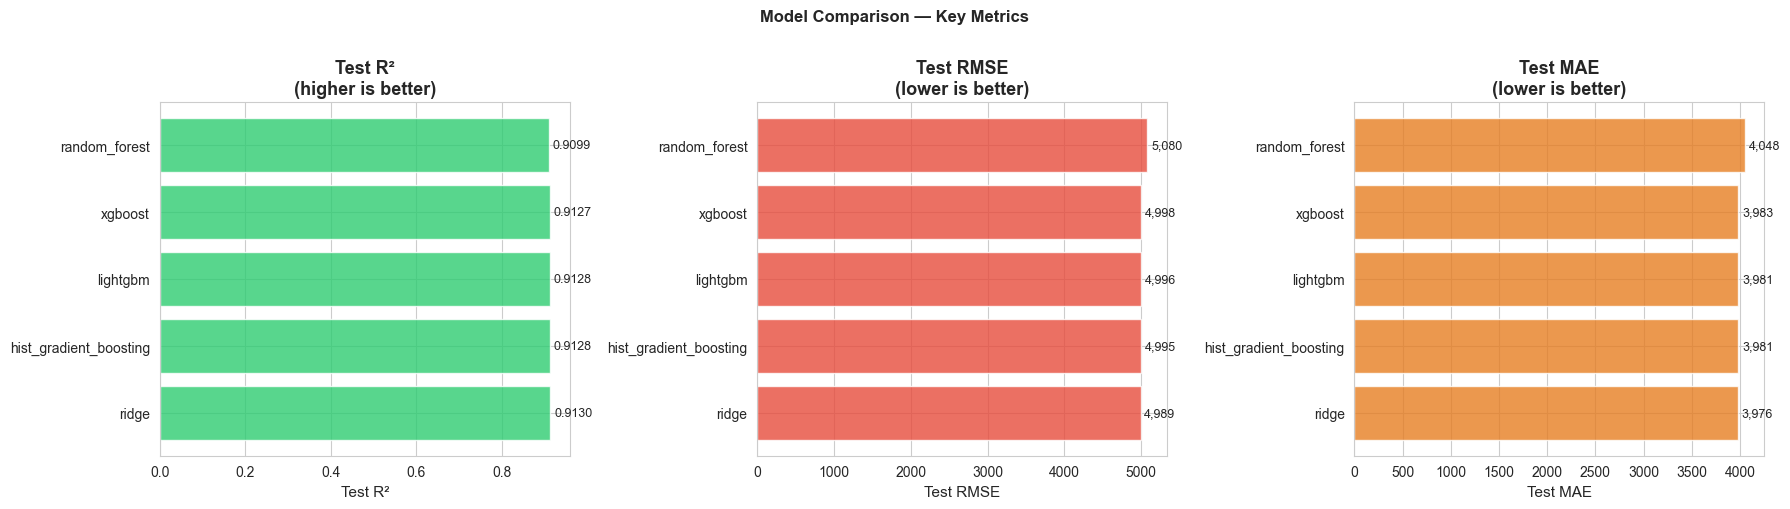

Saved → model_01_comparison.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ('Test R²',   axes[0], False, '#2ecc71'),
    ('Test RMSE', axes[1], True,  '#e74c3c'),
    ('Test MAE',  axes[2], True,  '#e67e22'),
]

for metric, ax, lower_better, color in metrics_to_plot:
    vals = table[metric].sort_values(ascending=lower_better)
    bars = ax.barh(vals.index, vals.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_title(f'{metric}\n({"lower" if lower_better else "higher"} is better)',
                 fontweight='bold')
    for bar, val in zip(bars, vals.values):
        fmt = f'{val:.4f}' if 'R²' in metric else f'{val:,.0f}'
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                fmt, va='center', fontsize=9)

plt.suptitle('Model Comparison — Key Metrics', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/model_01_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → model_01_comparison.png')

---
## 3. Best Model — Predictions vs Actual

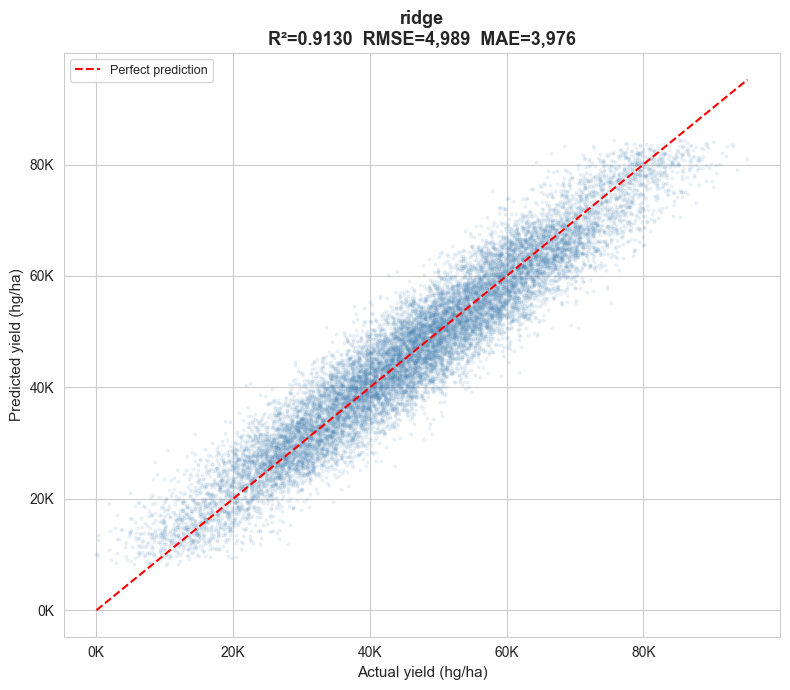

Saved → model_02_predictions_scatter.png


In [5]:
best_result  = results[best_name]
best_pipe    = best_result['pipeline']
y_pred_test  = best_result['y_pred']

fig, ax = plt.subplots(figsize=(8, 7))
plot_predictions_scatter(y_test, y_pred_test, best_name, ax=ax)
plt.tight_layout()
plt.savefig('../data/processed/model_02_predictions_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → model_02_predictions_scatter.png')

---
## 4. Best Model — Residuals Analysis

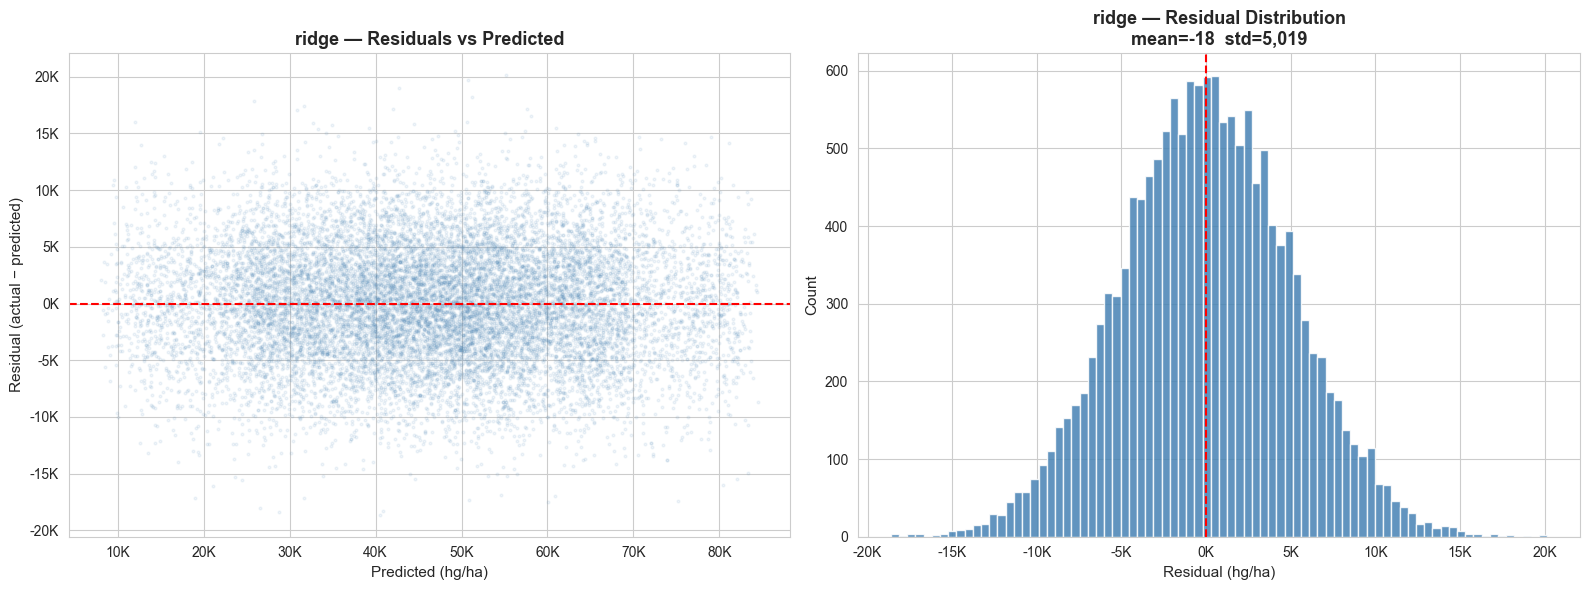

Saved → model_03_residuals.png

Residual summary (hg/ha):
  Mean   : -3.7
  Std    : 4,989.3
  P5     : -8,221.7
  P95    : 8,221.4
  |Max|  : 22,156.3


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_residuals(y_test, y_pred_test, best_name, axes=tuple(axes))
plt.tight_layout()
plt.savefig('../data/processed/model_03_residuals.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → model_03_residuals.png')

residuals = y_test - y_pred_test
print(f'\nResidual summary (hg/ha):')
print(f'  Mean   : {residuals.mean():,.1f}')
print(f'  Std    : {residuals.std():,.1f}')
print(f'  P5     : {np.percentile(residuals, 5):,.1f}')
print(f'  P95    : {np.percentile(residuals, 95):,.1f}')
print(f'  |Max|  : {np.abs(residuals).max():,.1f}')

---
## 5. Best Model — Feature Importance

For tree-based models, feature importance is the mean decrease in impurity (MDI) across all trees.

Feature importance not available for ridge: Model 'ridge' does not expose feature_importances_. Use a tree-based model (RF, XGBoost, LightGBM, HGB).


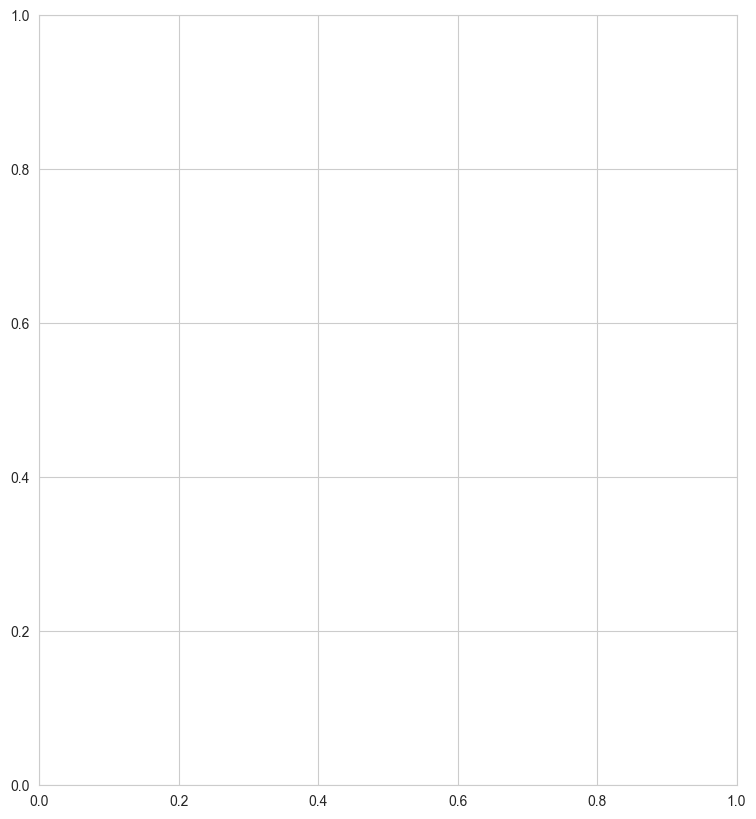

In [7]:
try:
    fig, ax = plt.subplots(figsize=(9, 10))
    plot_feature_importance(best_pipe, feature_cols, best_name, top_n=20, ax=ax)
    plt.tight_layout()
    plt.savefig('../data/processed/model_04_feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved → model_04_feature_importance.png')
except ValueError as e:
    print(f'Feature importance not available for {best_name}: {e}')

---
## 6. Cross-Validation RMSE Comparison

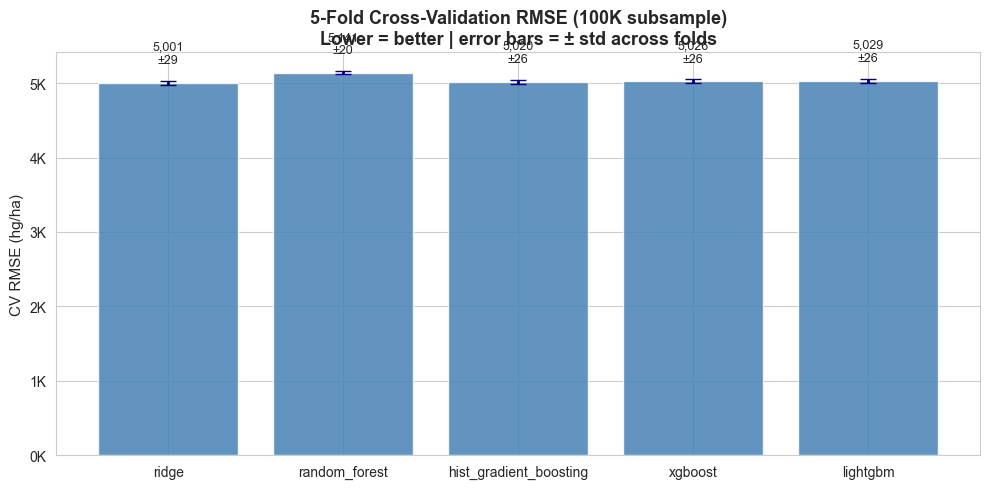

Saved → model_05_cv_rmse.png


In [8]:
model_names = list(results.keys())
cv_means    = [results[n]['cv_rmse_mean'] for n in model_names]
cv_stds     = [results[n]['cv_rmse_std']  for n in model_names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, cv_means, yerr=cv_stds, capsize=6,
              color='steelblue', alpha=0.85, edgecolor='white',
              error_kw={'elinewidth': 2, 'ecolor': 'navy'})

for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 200,
            f'{mean:,.0f}\n±{std:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('CV RMSE (hg/ha)')
ax.set_title('5-Fold Cross-Validation RMSE (100K subsample)\n'
             'Lower = better | error bars = ± std across folds',
             fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../data/processed/model_05_cv_rmse.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → model_05_cv_rmse.png')

---
## 7. All Models — Predictions vs Actual (panel)

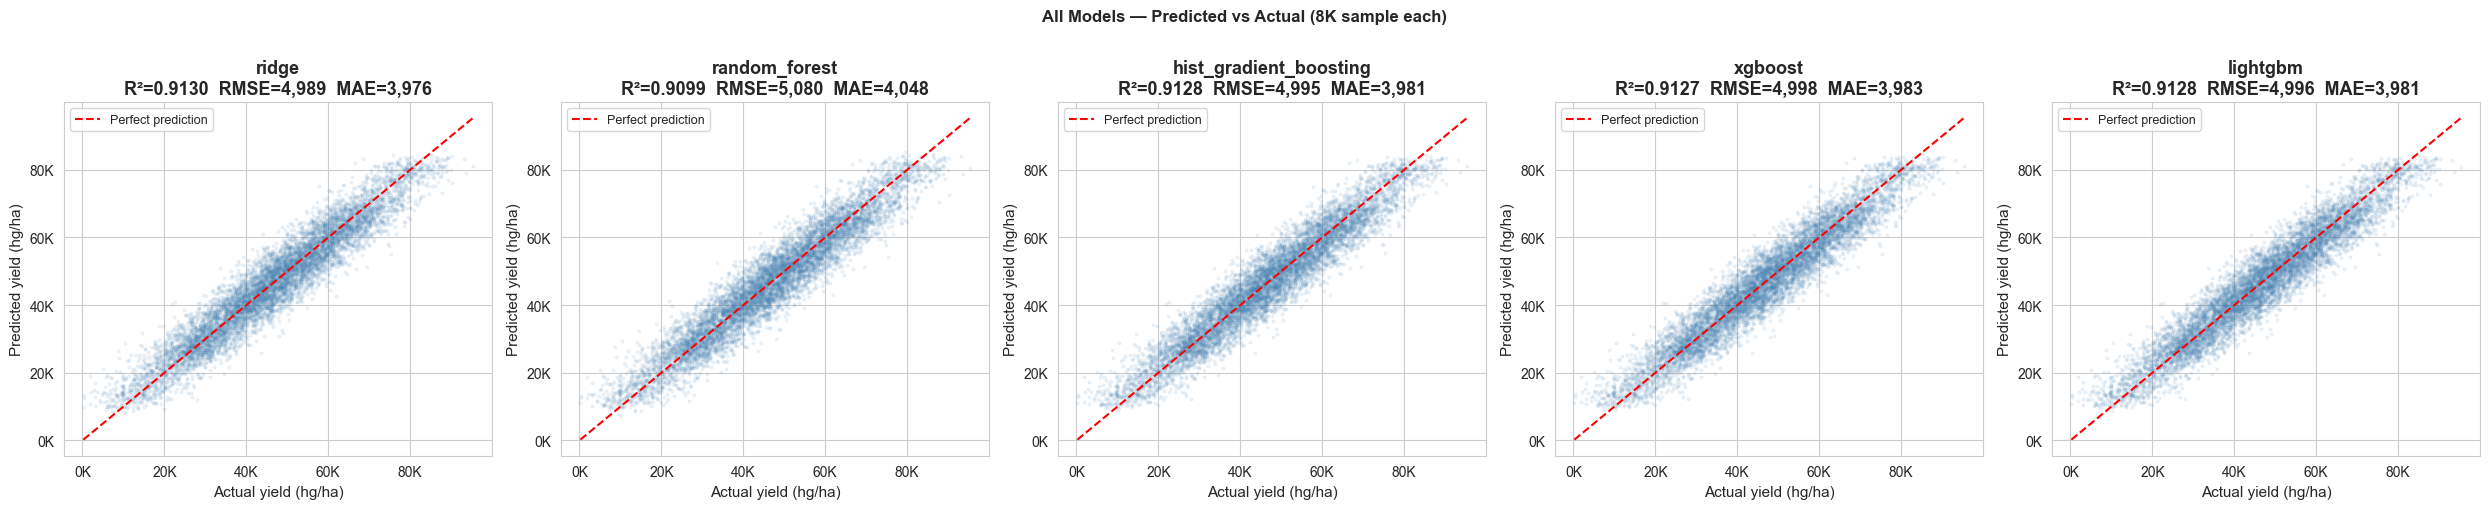

Saved → model_06_all_predictions.png


In [9]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

for ax, (name, res) in zip(axes, results.items()):
    plot_predictions_scatter(y_test, res['y_pred'], name, ax=ax, sample_size=8000)

plt.suptitle('All Models — Predicted vs Actual (8K sample each)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/model_06_all_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → model_06_all_predictions.png')

---
## 8. Summary

In [10]:
with open('../models/model_results.json') as f:
    summary = json.load(f)

best = summary['best_model']
bm   = summary['models'][best]

print('=== Phase 5: Model Training Summary ===')
print(f'Train rows     : {summary["train_rows"]:,}')
print(f'Test rows      : {summary["test_rows"]:,}')
print(f'Features       : {len(feature_cols)}')
print()
print(f'Best model     : {best}')
print(f'  Test R²      : {bm["test_r2"]:.4f}')
print(f'  Test RMSE    : {bm["test_rmse"]:,.0f} hg/ha ({bm["test_rmse"]/10000:.3f} t/ha)')
print(f'  Test MAE     : {bm["test_mae"]:,.0f} hg/ha ({bm["test_mae"]/10000:.3f} t/ha)')
print(f'  Test MAPE    : {bm["test_mape"]:.2f}%')
print(f'  CV RMSE      : {bm["cv_rmse_mean"]:,.0f} ± {bm["cv_rmse_std"]:,.0f} hg/ha')
print(f'  Train time   : {bm["train_time_s"]:.1f}s')
print()
print('Artefacts saved to models/:')
print('  best_model.pkl      — sklearn Pipeline (best model)')
print('  scaler.pkl          — StandardScaler fitted on training data')
print('  feature_names.json  — ordered feature column list')
print('  model_results.json  — comparison table (all 5 models)')
print()
print('MLflow experiments:')
print('  Run: mlflow ui --backend-store-uri mlflow/mlruns')
print()
print('=== Phase 5 Complete ===')

=== Phase 5: Model Training Summary ===
Train rows     : 533,195
Test rows      : 133,299
Features       : 36

Best model     : ridge
  Test R²      : 0.9130
  Test RMSE    : 4,989 hg/ha (0.499 t/ha)
  Test MAE     : 3,976 hg/ha (0.398 t/ha)
  Test MAPE    : 12.06%
  CV RMSE      : 5,001 ± 29 hg/ha
  Train time   : 1.4s

Artefacts saved to models/:
  best_model.pkl      — sklearn Pipeline (best model)
  scaler.pkl          — StandardScaler fitted on training data
  feature_names.json  — ordered feature column list
  model_results.json  — comparison table (all 5 models)

MLflow experiments:
  Run: mlflow ui --backend-store-uri mlflow/mlruns

=== Phase 5 Complete ===
